
=== ER: n=1000, m=1469 ===
Estimated robust beta-center ≈ 0.046; seeds: [470, 55, 80, 104, 218, 29]...
  -> FRC: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.17, beta0 ~ 0.300±0.001
  -> Degree: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.30, beta0 ~ 0.146±0.001
  -> Eigenvector: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.35, beta0 ~ 0.188±0.002
  -> EdgeBetweenness: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.33, beta0 ~ 0.159±0.002

Posterior-predictive accuracy on HOLDOUT (mean ± 90% CI)
Model              beta0̂     RMSEmean     RMSEremote    |Δt_peak|      |ΔR(∞)|
FRC                 0.300       0.0000         0.0000        0.000       0.0000
Degree              0.146       0.0042         0.0010        0.601       1.7499
Eigenvector         0.188       0.0052         0.0019        1.804       1.1397
EdgeBetweenness     0.1

/tmp/ipython-input-3466477842.py:409: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Rinf_abs = float(abs(np.trapz(I_pred_mean, dx=dt) - np.trapz(I_truth_mean, dx=dt)))


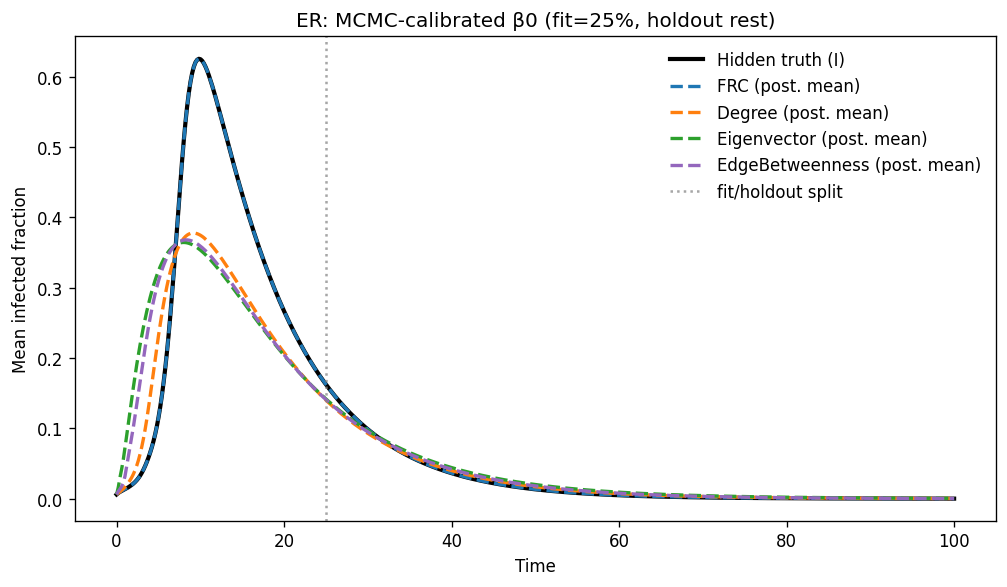

Saved figure: images/ER_mcmc_hidden_truth.png

=== WS: n=1000, m=5000 ===
Estimated robust beta-center ≈ 0.036; seeds: [739, 163, 918, 10, 58, 261]...
  -> FRC: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.42, beta0 ~ 0.300±0.004
  -> Degree: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.45, beta0 ~ 0.208±0.003
  -> Eigenvector: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.48, beta0 ~ 0.307±0.005
  -> EdgeBetweenness: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.46, beta0 ~ 0.141±0.002

Posterior-predictive accuracy on HOLDOUT (mean ± 90% CI)
Model              beta0̂     RMSEmean     RMSEremote    |Δt_peak|      |ΔR(∞)|
FRC                 0.300       0.0000         0.0000        0.000       0.0000
Degree              0.208       0.0007         0.0000        0.200       0.0273
Eigenvector         0.307       0.0004         0.0000   

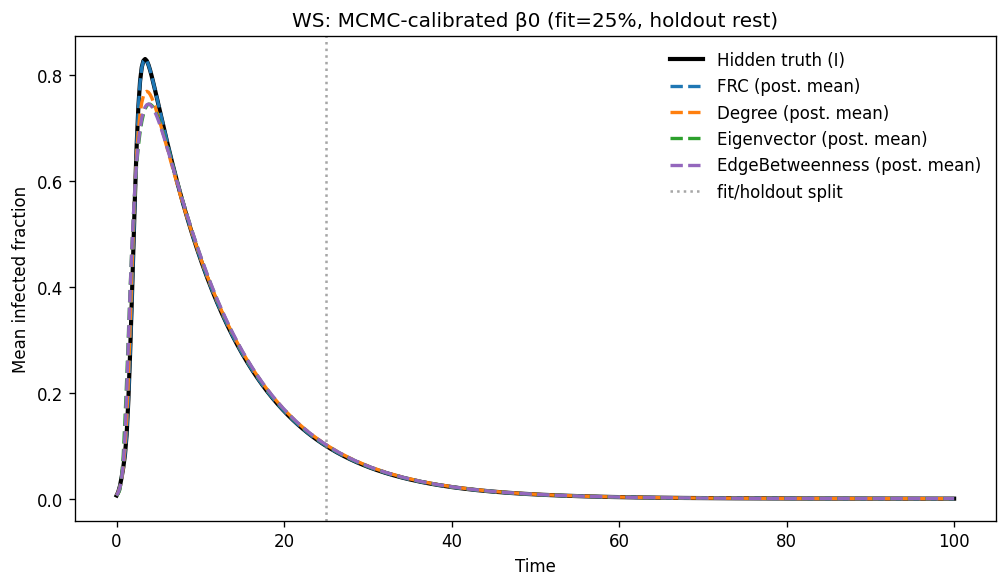

Saved figure: images/WS_mcmc_hidden_truth.png

=== BA: n=1000, m=2991 ===
Estimated robust beta-center ≈ 0.145; seeds: [4, 499, 786, 845, 924, 39]...
  -> FRC: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.32, beta0 ~ 0.300±0.003
  -> Degree: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.48, beta0 ~ 0.163±0.003
  -> Eigenvector: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.49, beta0 ~ 0.183±0.003
  -> EdgeBetweenness: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.46, beta0 ~ 0.167±0.002

Posterior-predictive accuracy on HOLDOUT (mean ± 90% CI)
Model              beta0̂     RMSEmean     RMSEremote    |Δt_peak|      |ΔR(∞)|
FRC                 0.300       0.0000         0.0000        0.000       0.0000
Degree              0.163       0.0037         0.0004        0.200       0.3174
Eigenvector         0.183       0.0032         0.0003    

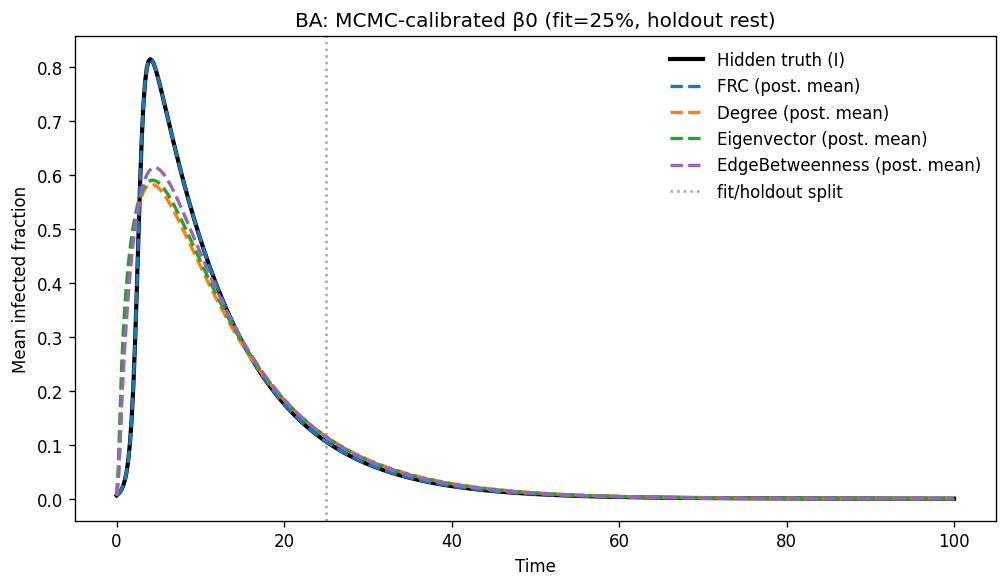

Saved figure: images/BA_mcmc_hidden_truth.png

=== PLC: n=1000, m=2991 ===
Estimated robust beta-center ≈ 0.150; seeds: [3, 559, 744, 106, 131, 135]...
  -> FRC: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.25, beta0 ~ 0.300±0.002
  -> Degree: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.50, beta0 ~ 0.160±0.002
  -> Eigenvector: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.43, beta0 ~ 0.190±0.003
  -> EdgeBetweenness: building B(.), growth-matched prior, running MCMC...
     MCMC: draws=600, accept≈0.45, beta0 ~ 0.165±0.002

Posterior-predictive accuracy on HOLDOUT (mean ± 90% CI)
Model              beta0̂     RMSEmean     RMSEremote    |Δt_peak|      |ΔR(∞)|
FRC                 0.300       0.0000         0.0000        0.000       0.0000
Degree              0.160       0.0037         0.0004        0.200       0.3467
Eigenvector         0.190       0.0026         0.0002  

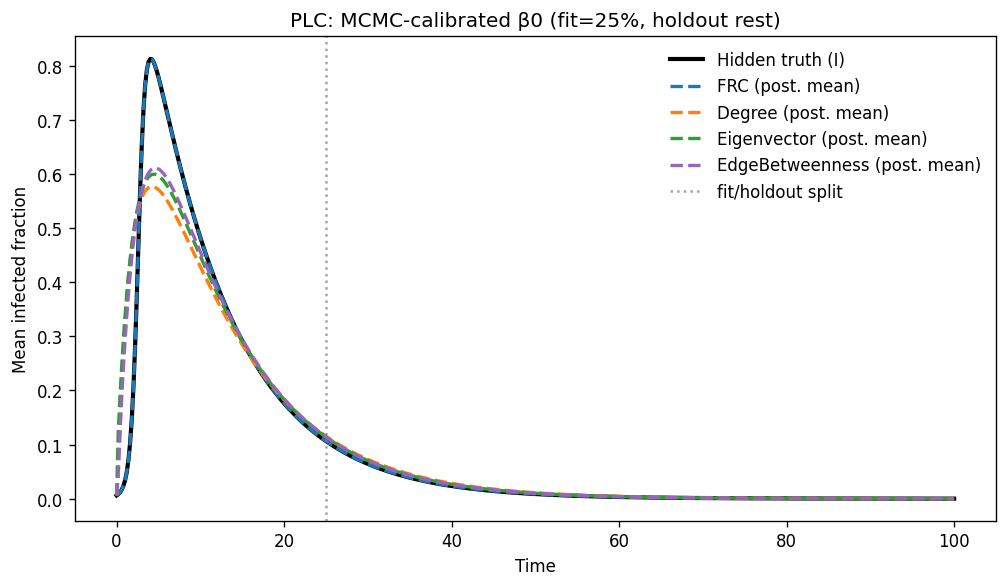

Saved figure: images/PLC_mcmc_hidden_truth.png


In [ ]:
# ================== Hidden-truth + MCMC calibration (undirected graphs, SIR) ==================
# Validates curvature-weighted transmission against advanced baselines under controlled truth.
# Now includes EdgeBetweenness end-to-end (calibration, metrics, plotting).
# ----------------------------------------------------------------------------------------------

import os, math, random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List

# ------------------------------ Repro / config ----------------------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

OUTDIR = "images"
os.makedirs(OUTDIR, exist_ok=True)

# Network sizes (as in manuscript)
N = 1000
P_ER = 0.003
WS_K, WS_P = 10, 0.1
BA_M = 3
PLC_M, PLC_P = 3, 0.05

# Epidemic timeline
T_MAX = 100.0
N_T = 500
TIME = np.linspace(0, T_MAX, N_T)
DT = float(TIME[1] - TIME[0])

# Transmission mapping
ALPHA = 1.0  # beta_ij = beta0 * exp(ALPHA * z_e_std)

# Hidden truth (what generates the "data")
BETA0_TRUE = 0.3
TRUTH_FEATURE = "FRC"

# Fitting window (fraction of TIME used for calibrating beta0)
FIT_FRAC = 0.25               # e.g., 25% of the curve for calibration
T_FIT_END = int(FIT_FRAC * N_T)

# MCMC settings
N_WARMUP = 200
N_SAMPLES = 600
ADAPT_EVERY = 25
TARGET_ACC = 0.30
INIT_STEP_SD = 0.2                 # initial proposal sd on log(beta0)
LIKELIHOOD_SIGMA_FRACTION = 0.03   # obs-noise scale as fraction of peak I_mean in fit window
CI_Q = (0.05, 0.95)                # 90% credible band

# Seeds
N_SEEDS = 6                        # number of initially infected nodes
EPS = 1e-12

# ==============================================================================================
#                               Curvature & Edge Features
# ==============================================================================================

class FormanRicciUndirected:
    """
    Standard undirected FRC with unit weights:
      F({u,v}) = w_e * ( w_u / w_e + w_v / w_e
                        - sum_{x~u, x!=v}  w_u / sqrt(w_e w_{ux})
                        - sum_{y~v, y!=u}  w_v / sqrt(w_e w_{vy}) )
    with all weights set to 1.
    Returns dict keyed by canonical (min,max) edges.
    """
    def __init__(self, G: nx.Graph):
        if not isinstance(G, nx.Graph) or G.is_directed():
            raise ValueError("FormanRicciUndirected requires an undirected Graph.")
        self.G = G

    def compute(self) -> Dict[Tuple, float]:
        F = {}
        for u, v in self.G.edges():
            we = wu = wv = 1.0
            su = sum(wu / math.sqrt(we * 1.0) for x in self.G.neighbors(u) if x != v)
            sv = sum(wv / math.sqrt(we * 1.0) for y in self.G.neighbors(v) if y != u)
            key = (u, v) if u < v else (v, u)
            F[key] = we * ((wu / we) + (wv / we) - su - sv)
        return F

def standardize_edge_feature(z: Dict[Tuple, float]) -> Dict[Tuple, float]:
    vals = np.array(list(z.values()), dtype=float)
    mu, sd = vals.mean(), vals.std()
    if sd <= 0 or not np.isfinite(sd):
        return {e: 0.0 for e in z}
    return {e: (v - mu) / sd for e, v in z.items()}

def edge_feature_uniform(G: nx.Graph) -> Dict[Tuple, float]:
    return {tuple(sorted((u, v))): 0.0 for u, v in G.edges()}

def edge_feature_degree(G: nx.Graph, eps: float = 1e-9) -> Dict[Tuple, float]:
    deg = dict(G.degree())
    z = {}
    for u, v in G.edges():
        key = tuple(sorted((u, v)))
        z[key] = math.log((deg[u] + eps) * (deg[v] + eps))
    return z

def edge_feature_edge_betweenness(G: nx.Graph) -> Dict[Tuple, float]:
    eb = nx.edge_betweenness_centrality(G, normalized=True)
    return {tuple(sorted(k)): v for k, v in eb.items()}

def node_eigenvector_centrality(G: nx.Graph) -> Dict:
    if not nx.is_connected(G):
        H = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        vals = nx.eigenvector_centrality_numpy(H)
        return {n: vals.get(n, 0.0) for n in G.nodes()}
    return nx.eigenvector_centrality_numpy(G)

def edge_feature_eigenvector(G: nx.Graph) -> Dict[Tuple, float]:
    xv = node_eigenvector_centrality(G)
    return {tuple(sorted((u, v))): (xv[u] + xv[v]) for u, v in G.edges()}

def edge_feature_kcore(G: nx.Graph) -> Dict[Tuple, float]:
    c = nx.core_number(G)
    return {tuple(sorted((u, v))): (c[u] + c[v]) for u, v in G.edges()}

def edge_feature_overlap(G: nx.Graph) -> Dict[Tuple, float]:
    z = {}
    for u, v in G.edges():
        Nu, Nv = set(G.neighbors(u)), set(G.neighbors(v))
        inter, uni = len(Nu & Nv), len(Nu | Nv)
        z[tuple(sorted((u, v)))] = inter / uni if uni > 0 else 0.0
    return z

def edge_feature_frc_undirected(G: nx.Graph) -> Dict[Tuple, float]:
    return FormanRicciUndirected(G).compute()

FEATURES = {
    "Uniform": edge_feature_uniform,
    "Degree": edge_feature_degree,
    "EdgeBetweenness": edge_feature_edge_betweenness,  # <— explicitly included baseline
    "Eigenvector": edge_feature_eigenvector,
    "KCore": edge_feature_kcore,
    "Overlap": edge_feature_overlap,
    "FRC": edge_feature_frc_undirected,
}

# ==============================================================================================
#                              Build contact matrix & SIR sim
# ==============================================================================================

def build_B_from_feature(G: nx.Graph, z_e_raw: Dict[Tuple, float], beta0: float, alpha: float = 1.0):
    """Construct symmetric contact matrix B from standardized edge feature."""
    z = standardize_edge_feature(z_e_raw)
    nodes = list(G.nodes())
    idx = {v: i for i, v in enumerate(nodes)}
    n = len(nodes)
    B = np.zeros((n, n), dtype=np.float64)
    for u, v in G.edges():
        key = tuple(sorted((u, v)))
        w = beta0 * math.exp(alpha * z.get(key, 0.0))
        i, j = idx[u], idx[v]
        B[i, j] = w
        B[j, i] = w
    np.fill_diagonal(B, 0.0)
    return B, nodes

def simulate_sir_euler_stable(B: np.ndarray,
                              seeds: List[int],
                              n: int,
                              tvec: np.ndarray,
                              gamma: float = 0.1) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Stable explicit Euler with clamping and light renormalization.
    S, I, R are node-wise probabilities; seeds start with I=1, S=0.
    """
    dt = float(tvec[1] - tvec[0])
    T = len(tvec)
    S = np.ones((T, n), dtype=np.float64)
    I = np.zeros((T, n), dtype=np.float64)
    R = np.zeros((T, n), dtype=np.float64)

    # seed
    S[0, seeds] = 0.0
    I[0, seeds] = 1.0

    for t in range(T - 1):
        lam = B @ I[t]                           # force of infection
        dS = -S[t] * lam
        dI = S[t] * lam - gamma * I[t]
        dR = gamma * I[t]
        # Euler step
        S[t+1] = S[t] + dt * dS
        I[t+1] = I[t] + dt * dI
        R[t+1] = R[t] + dt * dR
        # clamp to [0,1]
        S[t+1] = np.clip(S[t+1], 0.0, 1.0)
        I[t+1] = np.clip(I[t+1], 0.0, 1.0)
        R[t+1] = np.clip(R[t+1], 0.0, 1.0)
        # light renormalization (keeps S+I+R≈1, avoids drift)
        total = S[t+1] + I[t+1] + R[t+1] + EPS
        S[t+1] /= total
        I[t+1] /= total
        R[t+1] /= total
    return S, I, R

# ==============================================================================================
#                         Seeds: negative-FRC bridges + max–min spacing
# ==============================================================================================

def edge_feature_edge_betweenness_nodescore(G: nx.Graph) -> Dict[int, float]:
    """Helper: node 'bridgeiness' = sum of incident edge betweenness."""
    eb = edge_feature_edge_betweenness(G)
    s = {u: 0.0 for u in G.nodes()}
    for (u, v), w in eb.items():
        s[u] += w; s[v] += w
    return s

def pick_seeds_negfrc_maxmin(G: nx.Graph, k: int, frc: Dict[Tuple, float]) -> List[int]:
    if k <= 0:
        return []
    # nodes touching negative-FRC edges
    neg_nodes = set()
    for (u, v), f in frc.items():
        if f < 0:
            neg_nodes.add(u); neg_nodes.add(v)
    if not neg_nodes:
        # fallback: high-degree nodes
        cand = sorted(G.nodes(), key=lambda x: G.degree(x), reverse=True)[:max(10, k*5)]
    else:
        cand = list(neg_nodes)

    # greedy max–min spacing; seed with most "bridgey" node
    bridgeiness = edge_feature_edge_betweenness_nodescore(G)
    by_bridge = sorted(cand, key=lambda u: bridgeiness.get(u, 0.0), reverse=True)
    chosen = [by_bridge[0] if by_bridge else cand[0]]

    while len(chosen) < k:
        best_u, best_d = None, -1.0
        for u in cand:
            if u in chosen: continue
            dists = []
            for v in chosen:
                try:
                    d = nx.shortest_path_length(G, u, v)
                    dists.append(d)
                except nx.NetworkXNoPath:
                    continue
            score = min(dists) if dists else 0.0
            if score > best_d:
                best_d = score; best_u = u
        if best_u is None:
            best_u = random.choice([x for x in G.nodes() if x not in chosen])
        chosen.append(best_u)
    return chosen

# ==============================================================================================
#                      Early-growth prior (robust) & spectral fallback
# ==============================================================================================

def robust_early_growth_prior(I_mean: np.ndarray,
                              t: np.ndarray,
                              B_truth: np.ndarray,
                              gamma: float) -> float:
    """
    Estimate early exponential growth r via monotone-increasing window up to first peak.
    If slope <= 0 or window too short, fall back to spectral radius: r ≈ S0 * ρ(B) - γ.
    Returns a positive prior center for beta0.
    """
    inc = np.maximum(I_mean[1:] - I_mean[:-1], 0.0)
    start = int(np.argmax(inc > 0)) if np.any(inc > 0) else 0
    peak = int(np.argmax(I_mean))
    end = max(start + 5, min(peak, len(I_mean)-1))

    ok = (end - start) >= 5
    r_slope = None
    if ok:
        y = np.log(np.clip(I_mean[start:end], 1e-8, None))
        x = t[start:end]
        A = np.vstack([x, np.ones_like(x)]).T
        sol, *_ = np.linalg.lstsq(A, y, rcond=None)
        r_slope = float(sol[0])

    if (r_slope is None) or (r_slope <= 0) or (not np.isfinite(r_slope)):
        rho = float(np.max(np.linalg.eigvals(B_truth).real))
        r_slope = max(1e-4, rho - gamma)

    rho_truth = float(np.max(np.linalg.eigvals(B_truth).real))
    denom = max(1e-6, rho_truth - gamma)
    beta_center = BETA0_TRUE * (r_slope / denom)
    return float(max(1e-4, beta_center))

# ==============================================================================================
#                                 MCMC on log(beta0)
# ==============================================================================================

def mcmc_beta0_rw(model_name: str,
                  G: nx.Graph,
                  z_raw: Dict[Tuple, float],
                  seeds: List[int],
                  y_fit: np.ndarray,
                  t_fit: np.ndarray,
                  t_full: np.ndarray,
                  gamma: float,
                  beta_center: float,
                  noise_sigma: float,
                  step_sd_init: float = INIT_STEP_SD,
                  n_warmup: int = N_WARMUP,
                  n_samples: int = N_SAMPLES,
                  adapt_every: int = ADAPT_EVERY,
                  target_acc: float = TARGET_ACC):
    """
    Random-walk MCMC over log(beta0).
    Prior: log(beta0) ~ Normal(mu=log(beta_center), sd=0.6).
    Likelihood: y_fit ~ N(I_mean(beta0), sigma^2 I).
    Returns chain stats and posterior predictive summary curves.
    """
    n = G.number_of_nodes()
    z_std = standardize_edge_feature(z_raw)

    nodes = list(G.nodes())
    seed_idx = [nodes.index(s) for s in seeds]

    def simulate_meanI(beta):
        B, _ = build_B_from_feature(G, z_std, beta, ALPHA)
        S, I, R = simulate_sir_euler_stable(B, seed_idx, n, t_full, gamma)
        return I.mean(axis=1), B

    def log_prior(logb):
        return -0.5 * ((logb - math.log(beta_center)) / 0.6)**2

    def log_like(logb):
        beta = float(np.exp(logb))
        I_mean, _ = simulate_meanI(beta)
        resid = y_fit - I_mean[:len(t_fit)]
        return -0.5 * np.sum((resid / noise_sigma)**2)

    # initialize at beta_center
    logb = math.log(beta_center)
    lp = log_prior(logb) + log_like(logb)

    step_sd = step_sd_init
    acc = 0
    draws = []

    total_iters = n_warmup + n_samples
    for it in range(total_iters):
        prop = np.random.normal(logb, step_sd)
        lp_prop = log_prior(prop) + log_like(prop)
        accept = (np.log(np.random.rand() + EPS) < (lp_prop - lp))
        if accept:
            logb = prop
            lp = lp_prop
            if it >= n_warmup:
                acc += 1

        # adapt during warmup
        if (it < n_warmup) and ((it + 1) % adapt_every == 0):
            recent_acc = acc / max(1, (it + 1))
            if recent_acc < target_acc:
                step_sd *= 0.8
            else:
                step_sd *= 1.05
            step_sd = float(np.clip(step_sd, 0.02, 0.8))

        if it >= n_warmup:
            draws.append(logb)

    accept_rate = acc / max(1, n_samples)
    chain = np.array(draws, dtype=float)

    # Posterior predictive (mean curve + CI) on full horizon
    betas = np.exp(chain)
    preds = []
    for b in betas[:: max(1, len(betas)//200) ]:  # thin to speed plotting
        I_mean, _ = simulate_meanI(float(b))
        preds.append(I_mean)
    preds = np.vstack(preds) if len(preds) else None

    post_mean_beta = float(np.mean(betas))
    post_ci_beta = (float(np.quantile(betas, CI_Q[0])), float(np.quantile(betas, CI_Q[1])))

    post_mean_curve = None
    ci_lo = ci_hi = None
    if preds is not None:
        post_mean_curve = preds.mean(axis=0)
        ci_lo = np.quantile(preds, CI_Q[0], axis=0)
        ci_hi = np.quantile(preds, CI_Q[1], axis=0)

    return {
        "chain_logb": chain,
        "accept_rate": accept_rate,
        "beta_mean": post_mean_beta,
        "beta_ci": post_ci_beta,
        "curve_mean": post_mean_curve,
        "curve_lo": ci_lo,
        "curve_hi": ci_hi,
    }

# ==============================================================================================
#                                Metrics on holdout window
# ==============================================================================================

def holdout_metrics(I_truth_mean: np.ndarray,
                    I_pred_mean: np.ndarray,
                    t_fit_end: int,
                    dt: float) -> Dict[str, float]:
    T = len(I_truth_mean)
    a = t_fit_end
    rmse = float(np.sqrt(np.mean((I_pred_mean[a:T] - I_truth_mean[a:T])**2)))
    tp_truth = int(np.argmax(I_truth_mean))
    tp_pred = int(np.argmax(I_pred_mean))
    tpeak_abs = abs(tp_pred - tp_truth) * dt
    Rinf_abs = float(abs(np.trapz(I_pred_mean, dx=dt) - np.trapz(I_truth_mean, dx=dt)))
    return {"RMSE": rmse, "tpeak_abs": tpeak_abs, "|ΔR∞|": Rinf_abs}

# ==============================================================================================
#                                Hidden-truth + MCMC driver
# ==============================================================================================

def make_graphs():
    return {
        "ER":  nx.erdos_renyi_graph(N, P_ER, seed=SEED),
        "WS":  nx.watts_strogatz_graph(N, WS_K, WS_P, seed=SEED),
        "BA":  nx.barabasi_albert_graph(N, BA_M, seed=SEED),
        "PLC": nx.powerlaw_cluster_graph(N, PLC_M, PLC_P, seed=SEED),
    }

def run_all(gamma: float = 0.1, show_plots: bool = True):
    graphs = make_graphs()

    for name, G in graphs.items():
        print(f"\n=== {name}: n={G.number_of_nodes()}, m={G.number_of_edges()} ===")

        # ----- Hidden truth generation (FRC) -----
        z_truth = FEATURES[TRUTH_FEATURE](G)
        B_truth, nodes = build_B_from_feature(G, z_truth, BETA0_TRUE, ALPHA)
        frc_vals = edge_feature_frc_undirected(G)
        seeds_nodes = pick_seeds_negfrc_maxmin(G, N_SEEDS, frc_vals)
        seeds_idx = [nodes.index(u) for u in seeds_nodes]

        S_true, I_true, R_true = simulate_sir_euler_stable(B_truth, seeds_idx, len(nodes), TIME, gamma)
        I_true_mean = I_true.mean(axis=1)

        # ---- Prior center for beta0 (robust early growth; spectral fallback) ----
        beta_center = robust_early_growth_prior(I_true_mean, TIME, B_truth, gamma)
        sigma_like = max(1e-4, LIKELIHOOD_SIGMA_FRACTION * float(I_true_mean[:T_FIT_END].max()))

        # ---- Calibrate models by MCMC (NOW INCLUDES EdgeBetweenness) ----
        models_to_fit = ["FRC", "Degree", "Eigenvector", "EdgeBetweenness"]
        results = {}

        print(f"Estimated robust beta-center ≈ {beta_center:.3f}; seeds: {seeds_nodes[:6]}...")
        for mdl in models_to_fit:
            print(f"  -> {mdl}: building B(.), growth-matched prior, running MCMC...")
            z_raw = FEATURES[mdl](G)
            fit = mcmc_beta0_rw(
                model_name=mdl,
                G=G,
                z_raw=z_raw,
                seeds=seeds_nodes,           # node IDs
                y_fit=I_true_mean[:T_FIT_END],
                t_fit=TIME[:T_FIT_END],
                t_full=TIME,
                gamma=gamma,
                beta_center=beta_center,
                noise_sigma=sigma_like
            )
            print(f"     MCMC: draws={len(fit['chain_logb'])}, accept≈{fit['accept_rate']:.2f}, "
                  f"beta0 ~ {fit['beta_mean']:.3f}±{np.std(np.exp(fit['chain_logb'])):.3f}")
            results[mdl] = fit

        # ---- Holdout accuracy ----
        print("\nPosterior-predictive accuracy on HOLDOUT (mean ± 90% CI)")
        print(f"{'Model':16s} {'beta0̂':>8s} {'RMSEmean':>12s} {'RMSEremote':>14s} {'|Δt_peak|':>12s} {'|ΔR(∞)|':>12s}")
        for mdl in models_to_fit:
            fit = results[mdl]
            pm = fit["curve_mean"]
            if pm is None:
                print(f"{mdl:16s} {'nan':>8s} {'nan':>12s} {'nan':>14s} {'nan':>12s} {'nan':>12s}")
                continue
            # central (mean)
            m_c = holdout_metrics(I_true_mean, pm, T_FIT_END, DT)
            # "remote" RMSE: only the second half of the holdout
            mid = T_FIT_END + (N_T - T_FIT_END)//2
            rmse_remote = float(np.sqrt(np.mean((pm[mid:] - I_true_mean[mid:])**2)))
            print(f"{mdl:16s} {fit['beta_mean']:8.3f} "
                  f"{m_c['RMSE']:12.4f} {rmse_remote:14.4f} "
                  f"{m_c['tpeak_abs']:12.3f} {m_c['|ΔR∞|']:12.4f}")

        # ---- Plot: truth vs posterior means (with CI for FRC) ----
        plt.figure(figsize=(8.5, 5), dpi=120)
        plt.plot(TIME, I_true_mean, color="black", lw=2.5, label="Hidden truth (I)")

        # FRC
        if results["FRC"]["curve_mean"] is not None:
            plt.plot(TIME, results["FRC"]["curve_mean"], ls="--", color="tab:blue", lw=2.0,
                     label="FRC (post. mean)")
            if (results["FRC"]["curve_lo"] is not None) and (results["FRC"]["curve_hi"] is not None):
                plt.fill_between(TIME,
                                 results["FRC"]["curve_lo"],
                                 results["FRC"]["curve_hi"],
                                 color="tab:blue", alpha=0.12)

        # Degree
        if results.get("Degree", {}).get("curve_mean") is not None:
            plt.plot(TIME, results["Degree"]["curve_mean"], ls="--", color="tab:orange", lw=2.0,
                     label="Degree (post. mean)")

        # Eigenvector
        if results.get("Eigenvector", {}).get("curve_mean") is not None:
            plt.plot(TIME, results["Eigenvector"]["curve_mean"], ls="--", color="tab:green", lw=2.0,
                     label="Eigenvector (post. mean)")

        # EdgeBetweenness (NEW)
        if results.get("EdgeBetweenness", {}).get("curve_mean") is not None:
            plt.plot(TIME, results["EdgeBetweenness"]["curve_mean"], ls="--", color="tab:purple", lw=2.0,
                     label="EdgeBetweenness (post. mean)")

        plt.axvline(TIME[T_FIT_END], color="gray", ls=":", alpha=0.7, label="fit/holdout split")
        plt.xlabel("Time")
        plt.ylabel("Mean infected fraction")
        plt.title(f"{name}: MCMC-calibrated β0 (fit={int(FIT_FRAC*100)}%, holdout rest)")
        plt.legend(frameon=False)
        plt.tight_layout()
        path = os.path.join(OUTDIR, f"{name}_mcmc_hidden_truth.png")
        plt.savefig(path, dpi=300)
        if show_plots:
            plt.show()
        else:
            plt.close()
        print(f"Saved figure: {path}")

# ------------------------------ Run ----------------------------------------------------------
if __name__ == "__main__":
    run_all(gamma=0.1, show_plots=True)